Imports

In [1]:
import numpy as np
np.random.seed(42)
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

In [2]:
DATA_PATH='Data/mnist.npz'

#### Data processing

Load data using numpy

In [3]:
data = np.load(DATA_PATH)
print(data.files)

['x_test', 'x_train', 'y_train', 'y_test']


In [4]:
X_train = data['x_train']
y_train = data['y_train']

X_test = data['x_test']
y_test = data['y_test']

In [5]:
print(X_train.shape, y_train.shape)  
print(X_test.shape, y_test.shape)   

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


Flatten and Normalize

In [6]:
X_train = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0

In [7]:
print(X_train.shape, y_train.shape)  
print(X_test.shape, y_test.shape)   

(60000, 784) (60000,)
(10000, 784) (10000,)


Select data corresponding to classes 0, 1 and 2

In [8]:
classes = [0, 1, 2]

y_train_idx = [i for i in range(y_train.shape[0]) if y_train[i] in classes]
y_test_idx = [i for i in range(y_test.shape[0]) if y_test[i] in classes]

X_train = X_train[y_train_idx, :]
X_test = X_test[y_test_idx, :]
y_train = y_train[y_train_idx]
y_test = y_test[y_test_idx]

In [9]:
print("X_train.shape:", X_train.shape)
print("y_train.shape:", y_train.shape)
print("X_test.shape:", X_test.shape)
print("y_test.shape:", y_test.shape)

X_train.shape: (18623, 784)
y_train.shape: (18623,)
X_test.shape: (3147, 784)
y_test.shape: (3147,)


In [10]:
d = X_train.shape[1]
N_train = X_train.shape[0]
N_test = X_test.shape[0]

X = (N,d)

y = (N,)

d = 28x28 = 784

For train, N=18623

For test, N=3147

In [11]:
def plot_images(X, title, cols=5):
    num_images = len(X)
    rows = (num_images + cols - 1) // cols
    
    plt.figure(figsize=(cols*2, rows*2))
    if title:
        plt.suptitle(title)
    
    for i in range(num_images):
        plt.subplot(rows, cols, i+1)
        plt.imshow(X[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show() 

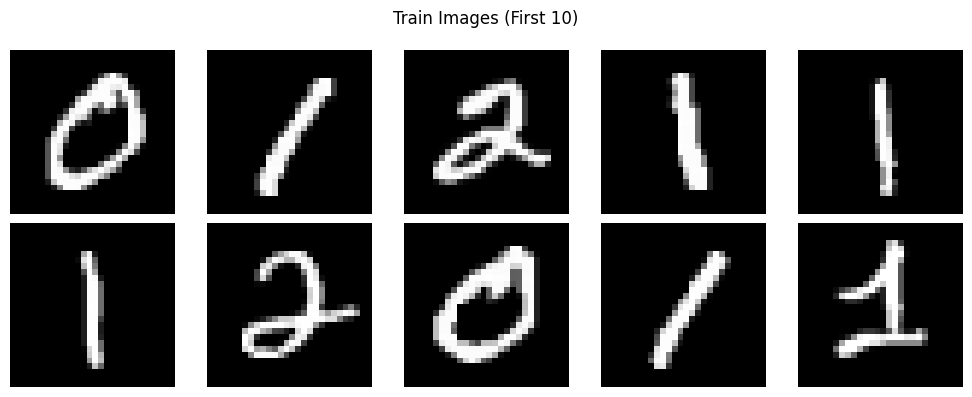

In [12]:
plot_images(X_train[:10],'Train Images (First 10)')

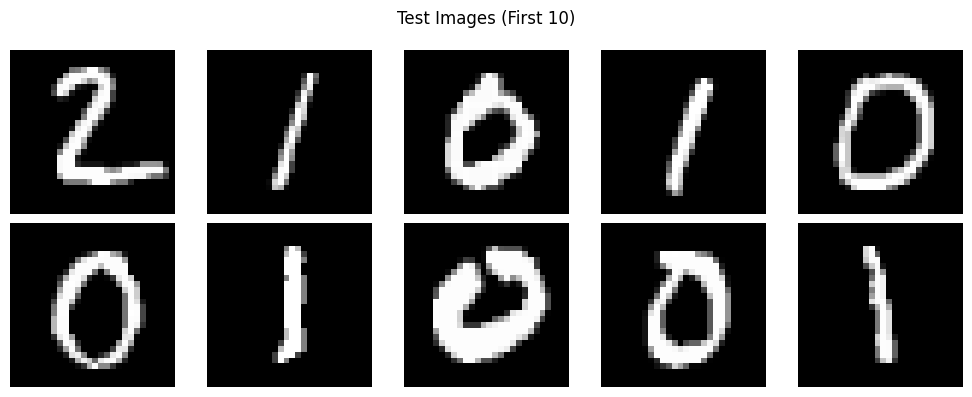

In [13]:
plot_images(X_test[:10],'Test Images (First 10)')

#### PCA implementation

Mean of the data:

$\mu = \frac{1}{N}\sum_{i=1}^{N} x_i$

Mean centered data:

$X_c = X - \mu$

Covariance matrix:

$S = \frac{X_c X_c^T}{N}$

Eigenvalue decomposition:

$S u_i = \lambda_i u_i$

Projection matrix using the top $p$ eigenvectors:

$U_p = [u_1, u_2, ..., u_p]$

Low dimensional representation:

$Y = U_p^T X_c$

In [14]:
def pca_fit(X,p):
    
    mu = np.mean(X, axis=0, keepdims=True)
    X_centered = X - mu

    cov_matrix = 1/X.shape[0] * X_centered.T @ X_centered

    # Eigenvalue problem on covariance matrix
    eigvalues, eigvectors = np.linalg.eigh(cov_matrix)

    # sort eigenvectors in descending order of eigenvalues
    eig_idx = np.argsort(eigvalues)[::-1]      
    eigvalues = eigvalues[eig_idx]
    eigvectors = eigvectors[:, eig_idx] 

    eigenvectors_p = eigvectors[:, :p]

    return eigenvectors_p, mu
    
def pca_transform(X, eigenvectors_p, mu):
    return (X - mu) @ eigenvectors_p

#### Ridge Regression implementation

Objective function:

$\mathcal{L}(w) = \|y - Xw\|_2^2 + \lambda \|w\|_2^2$

Expanded form:

$\mathcal{L}(w) = (y - Xw)^T (y - Xw) + \lambda w^T w$

Gradient w.r.t. $w$:

$\nabla_w \mathcal{L} = -2X^T(y - Xw) + 2\lambda w$

Set gradient to zero:

$X^T X w + \lambda w = X^T y$

Solution:

$w = (X^T X + \lambda I)^{-1} X^T y$


In [15]:
def ridge_regression_fit(X, y, l):
    N, d = X.shape
    I = np.eye(d)
    W = np.linalg.solve(X.T @ X + l * I, X.T @ y)
    return W

#### Lasso Regression implementation

Objective function:

$\mathcal{L}(w) = \|y - Xw\|_2^2 + \lambda \|w\|_1$

Expanded form:

$\mathcal{L}(w) = (y - Xw)^T (y - Xw) + \lambda \sum_{i=1}^{d} |w_i|$

Key idea:

L1 regularization encourages sparsity, driving some weights exactly to zero.

Optimization:

There is no closed-form solution.

Lasso is solved using iterative methods such as coordinate descent.

(Note: We use a built-in implementation from scikit-learn, 
which internally solves Lasso using coordinate descent.)

In [16]:
def lasso_regression_fit(X, y, l):
    model = Lasso(alpha=l)
    model.fit(X,y)
    return model.coef_.reshape(-1, 1)

In [17]:
# One vs Rest Conversion
def get_ovr_targets(y_labels, class_k):
    return (y_labels == class_k).astype(float)

# MSE 
def compute_mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

# Classification Accuracy
def compute_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

### Experiment1: Train models for different values of λ

In [18]:
W,mu = pca_fit(X_train, 10)
X_train_10 = pca_transform(X_train, W, mu)
X_test_10 = pca_transform(X_test, W, mu)

lambdas = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100] 

small_lim = 1e-6

results = {
    'ridge': {k: {'train_mse': [], 'val_mse': [], 'coefs': []} for k in classes},
    'lasso': {k: {'train_mse': [], 'val_mse': [], 'coefs': [], 'non_zeros': []} for k in classes}
}

for l in lambdas:
    
    print(f"\nLambda: {l:.4e}")
    
    for k in classes:
        
        print(f"Class {k}")
        
        # Get OVR targets for class k
        y_train_k = get_ovr_targets(y_train, k).reshape(-1, 1)
        y_test_k = get_ovr_targets(y_test, k).reshape(-1, 1)
        
        # Fit Ridge Regression
        W_ridge = ridge_regression_fit(X_train_10, y_train_k, l)
        
        # Train MSE
        train_mse_ridge = compute_mse(y_train_k, X_train_10 @ W_ridge)
        results['ridge'][k]['train_mse'].append(train_mse_ridge)
        
        # Y predicted and Val MSE
        y_k_pred_ridge = X_test_10 @ W_ridge
        val_mse_ridge = compute_mse(y_test_k, y_k_pred_ridge)
        results['ridge'][k]['val_mse'].append(val_mse_ridge)
        
        # Store coefficients
        results['ridge'][k]['coefs'].append(W_ridge.flatten())
        
        # Fit Lasso Regression
        W_lasso = lasso_regression_fit(X_train_10, y_train_k, l).reshape(-1, 1)
        
        # Train MSE
        train_mse_lasso = compute_mse(y_train_k, X_train_10 @ W_lasso)
        results['lasso'][k]['train_mse'].append(train_mse_lasso)
        
        # Y predicted and Val MSE
        y_k_pred_lasso = X_test_10 @ W_lasso
        val_mse_lasso = compute_mse(y_test_k, y_k_pred_lasso)
        results['lasso'][k]['val_mse'].append(val_mse_lasso)

        # Store coefficients 
        results['lasso'][k]['coefs'].append(W_lasso.flatten())
        
        # Count non-zero(not very small) coefficients
        results['lasso'][k]['non_zeros'].append(np.sum(np.abs(W_lasso) > small_lim))
        
        print(f"  Ridge  | Train: {train_mse_ridge:.4e} | Val: {val_mse_ridge:.4e}")
        print(f"  Lasso  | Train: {train_mse_lasso:.4e} | Val: {val_mse_lasso:.4e}")
        
        
    ridge_train_avg = np.mean([results['ridge'][k]['train_mse'][-1] for k in classes])
    ridge_val_avg   = np.mean([results['ridge'][k]['val_mse'][-1] for k in classes])

    lasso_train_avg = np.mean([results['lasso'][k]['train_mse'][-1] for k in classes])
    lasso_val_avg   = np.mean([results['lasso'][k]['val_mse'][-1] for k in classes])

    print("Average")
    print(f"  Ridge  | Train: {ridge_train_avg:.4e} | Val: {ridge_val_avg:.4e}")
    print(f"  Lasso  | Train: {lasso_train_avg:.4e} | Val: {lasso_val_avg:.4e}")
        
        


Lambda: 1.0000e-04
Class 0
  Ridge  | Train: 1.3242e-01 | Val: 1.2967e-01
  Lasso  | Train: 1.3242e-01 | Val: 1.2967e-01
Class 1
  Ridge  | Train: 1.8105e-01 | Val: 1.8616e-01
  Lasso  | Train: 1.8105e-01 | Val: 1.8616e-01
Class 2
  Ridge  | Train: 1.7116e-01 | Val: 1.7257e-01
  Lasso  | Train: 1.7116e-01 | Val: 1.7258e-01
Average
  Ridge  | Train: 1.6154e-01 | Val: 1.6280e-01
  Lasso  | Train: 1.6154e-01 | Val: 1.6280e-01

Lambda: 1.0000e-03
Class 0
  Ridge  | Train: 1.3242e-01 | Val: 1.2967e-01
  Lasso  | Train: 1.3242e-01 | Val: 1.2969e-01
Class 1
  Ridge  | Train: 1.8105e-01 | Val: 1.8616e-01
  Lasso  | Train: 1.8105e-01 | Val: 1.8614e-01
Class 2
  Ridge  | Train: 1.7116e-01 | Val: 1.7257e-01
  Lasso  | Train: 1.7117e-01 | Val: 1.7267e-01
Average
  Ridge  | Train: 1.6154e-01 | Val: 1.6280e-01
  Lasso  | Train: 1.6155e-01 | Val: 1.6283e-01

Lambda: 1.0000e-02
Class 0
  Ridge  | Train: 1.3242e-01 | Val: 1.2967e-01
  Lasso  | Train: 1.3285e-01 | Val: 1.3019e-01
Class 1
  Ridge  | Tra

Plot MSE vs λ (Ridge, Lasso)

In [19]:
log_lambdas = np.log10(lambdas)

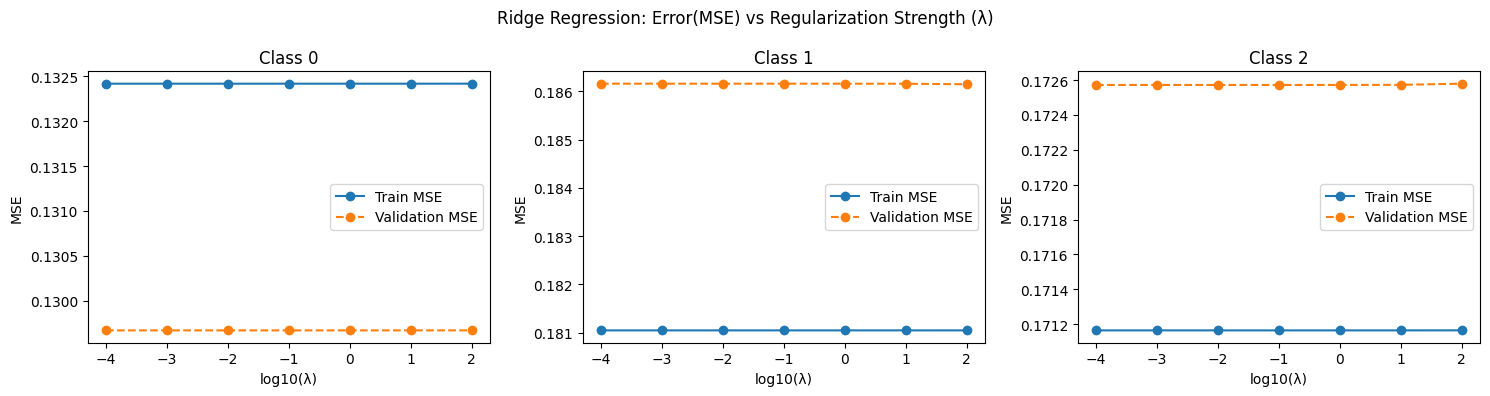

In [20]:
fig, axes = plt.subplots(1, len(classes), figsize=(15,4))

for i, k in enumerate(classes):
    ax = axes[i]
    
    ax.plot(log_lambdas, results['ridge'][k]['train_mse'], marker='o', label='Train MSE')
    ax.plot(log_lambdas, results['ridge'][k]['val_mse'], marker='o', linestyle='--', label='Validation MSE')
    
    ax.set_title(f'Class {k}')
    ax.set_xlabel('log10(λ)')
    ax.set_ylabel('MSE')
    ax.legend()

fig.suptitle('Ridge Regression: Error(MSE) vs Regularization Strength (λ)')

plt.tight_layout()
plt.show()

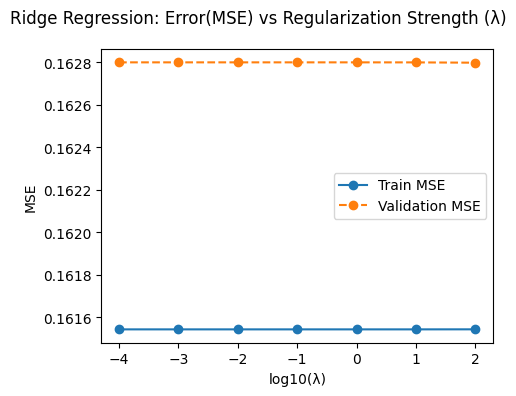

In [21]:
fig, axes = plt.subplots(1, 1, figsize=(5,4))

ax = axes

ridge_train_avg = [
    np.mean([results['ridge'][k]['train_mse'][i] for k in classes])
    for i in range(len(lambdas))
]

ridge_val_avg = [
    np.mean([results['ridge'][k]['val_mse'][i] for k in classes])
    for i in range(len(lambdas))
]

ax.plot(log_lambdas, ridge_train_avg, marker='o', label='Train MSE')
ax.plot(log_lambdas, ridge_val_avg, marker='o', linestyle='--', label='Validation MSE')

ax.set_xlabel('log10(λ)')
ax.set_ylabel('MSE')
ax.legend()

fig.suptitle('Ridge Regression: Error(MSE) vs Regularization Strength (λ)')

plt.tight_layout()
plt.show()

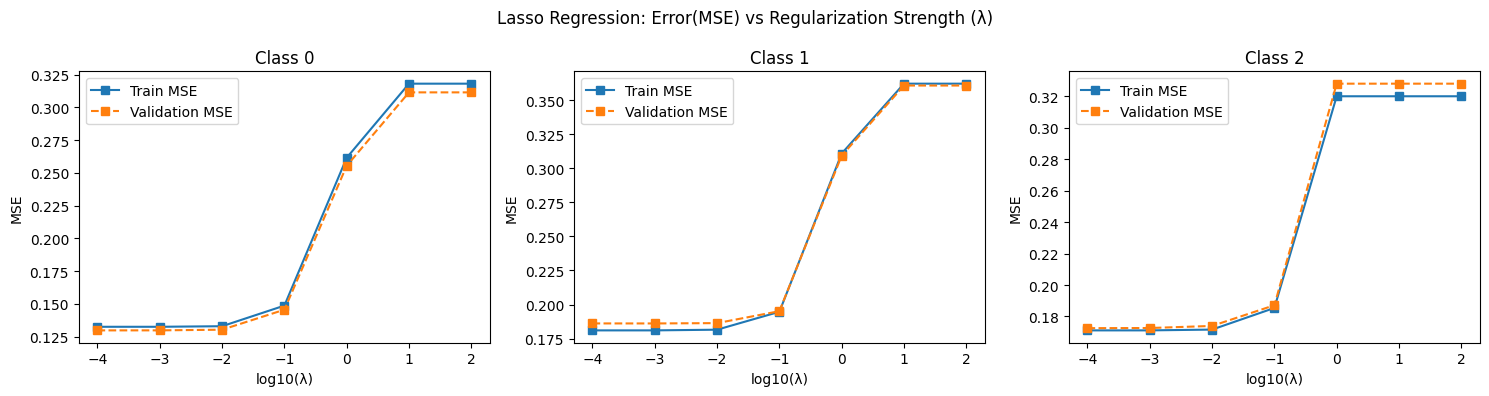

In [22]:
fig, axes = plt.subplots(1, len(classes), figsize=(15,4))

for i, k in enumerate(classes):
    ax = axes[i]
    
    ax.plot(log_lambdas, results['lasso'][k]['train_mse'], marker='s', label='Train MSE')
    ax.plot(log_lambdas, results['lasso'][k]['val_mse'], marker='s', linestyle='--', label='Validation MSE')
    
    ax.set_title(f'Class {k}')
    ax.set_xlabel('log10(λ)')
    ax.set_ylabel('MSE')
    ax.legend()

fig.suptitle('Lasso Regression: Error(MSE) vs Regularization Strength (λ)')

plt.tight_layout()
plt.show()

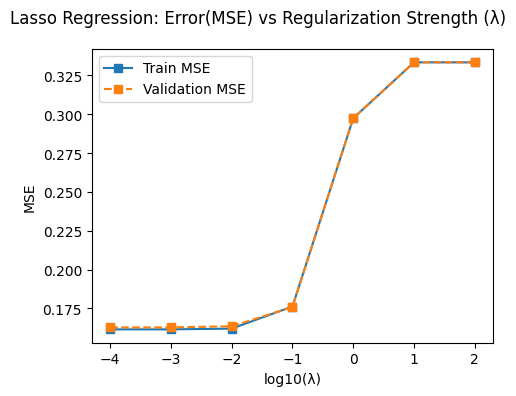

In [23]:
fig, axes = plt.subplots(1, 1, figsize=(5,4))

ax = axes

lasso_train_avg = [
    np.mean([results['lasso'][k]['train_mse'][i] for k in classes])
    for i in range(len(lambdas))
]

lasso_val_avg = [
    np.mean([results['lasso'][k]['val_mse'][i] for k in classes])
    for i in range(len(lambdas))
]

ax.plot(log_lambdas, lasso_train_avg, marker='s', label='Train MSE')
ax.plot(log_lambdas, lasso_val_avg, marker='s', linestyle='--', label='Validation MSE')

ax.set_xlabel('log10(λ)')
ax.set_ylabel('MSE')
ax.legend()

fig.suptitle('Lasso Regression: Error(MSE) vs Regularization Strength (λ)')

plt.tight_layout()
plt.show()

Plot Number of non-zero coefficents vs λ (Lasso)

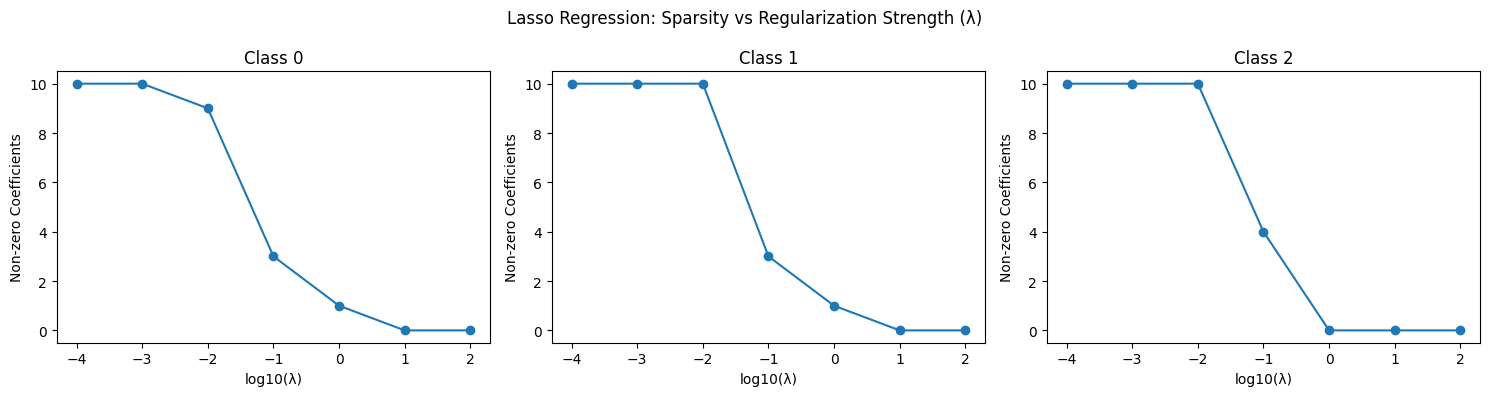

In [24]:
fig, axes = plt.subplots(1, len(classes), figsize=(15,4))

fig.suptitle("Lasso Regression: Sparsity vs Regularization Strength (λ)")

for i, k in enumerate(classes):
    ax = axes[i]
    
    ax.plot(log_lambdas, results['lasso'][k]['non_zeros'], marker='o')
    
    ax.set_title(f'Class {k}')
    ax.set_xlabel('log10(λ)')
    ax.set_ylabel('Non-zero Coefficients')

plt.tight_layout()
plt.show()

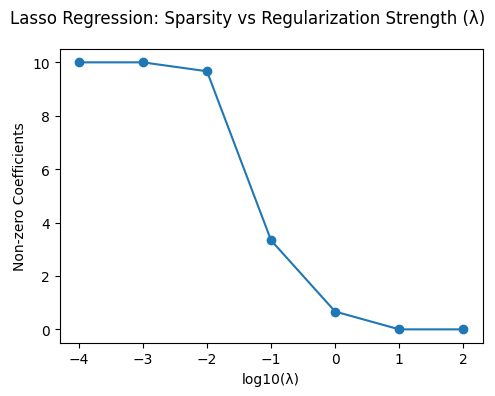

In [25]:
fig, axes = plt.subplots(1, 1, figsize=(5,4))

fig.suptitle("Lasso Regression: Sparsity vs Regularization Strength (λ)")

ax = axes

lasso_nz_avg = [
    np.mean([results['lasso'][k]['non_zeros'][i] for k in classes])
    for i in range(len(lambdas))
]

ax.plot(log_lambdas, lasso_nz_avg, marker='o')

ax.set_xlabel('log10(λ)')
ax.set_ylabel('Non-zero Coefficients')

plt.tight_layout()
plt.show()

Plot Regularization paths vs λ (Ridge, Lasso)

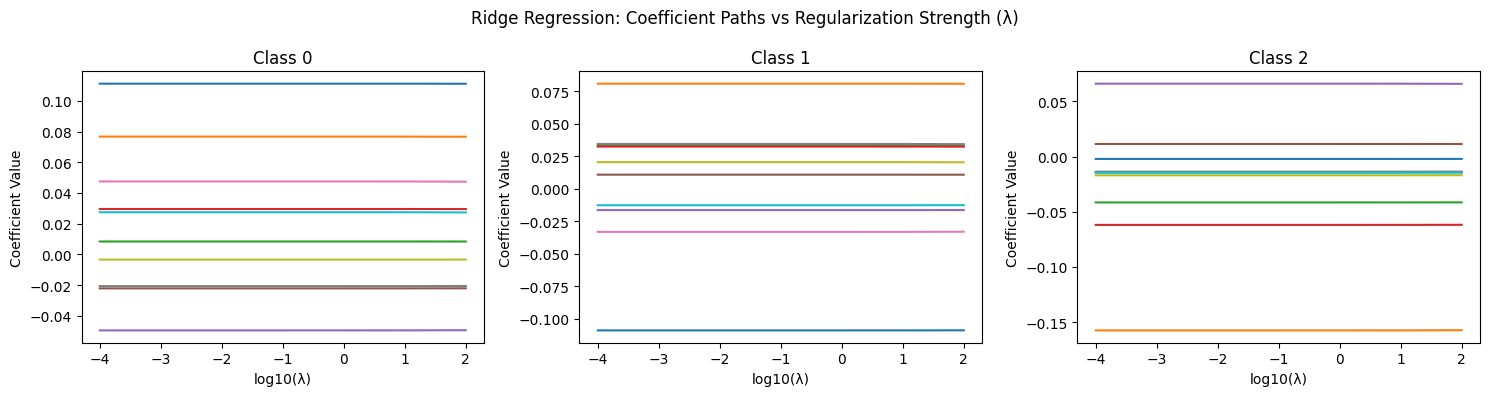

In [26]:
fig, axes = plt.subplots(1, len(classes), figsize=(15,4))
fig.suptitle('Ridge Regression: Coefficient Paths vs Regularization Strength (λ)')

for i, k in enumerate(classes):
    ax = axes[i]
    
    coefs = np.array(results['ridge'][k]['coefs'])  
    
    for j in range(coefs.shape[1]):
        ax.plot(log_lambdas, coefs[:, j])
    
    ax.set_title(f'Class {k}')
    ax.set_xlabel('log10(λ)')
    ax.set_ylabel('Coefficient Value')

plt.tight_layout()
plt.show()

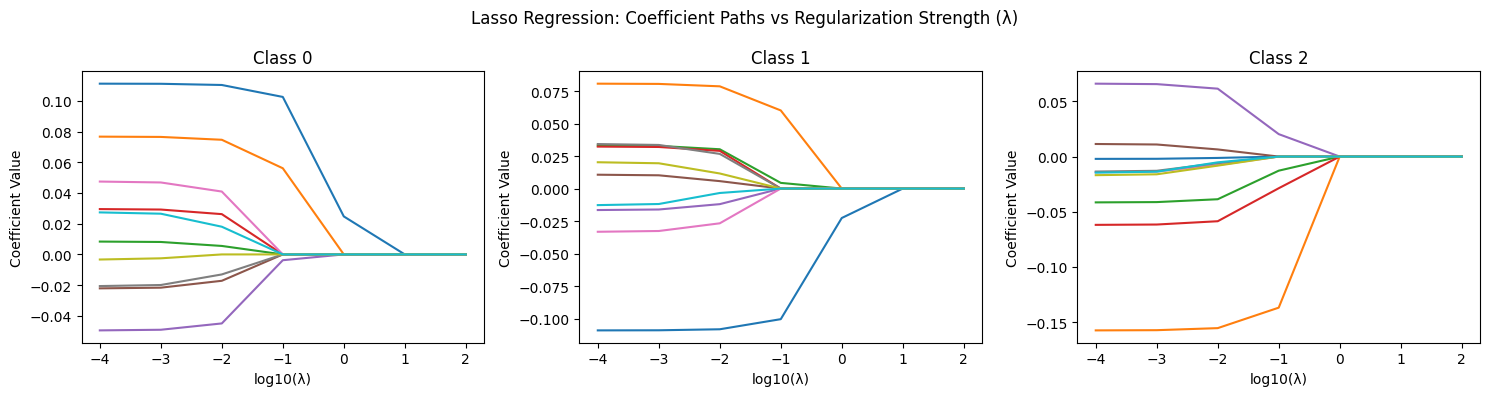

In [27]:
fig, axes = plt.subplots(1, len(classes), figsize=(15,4))
fig.suptitle('Lasso Regression: Coefficient Paths vs Regularization Strength (λ)')

for i, k in enumerate(classes):
    ax = axes[i]
    
    coefs = np.array(results['lasso'][k]['coefs']) 
    
    for j in range(coefs.shape[1]):
        ax.plot(log_lambdas, coefs[:, j])
    
    ax.set_title(f'Class {k}')
    ax.set_xlabel('log10(λ)')
    ax.set_ylabel('Coefficient Value')

plt.tight_layout()
plt.show()

Determine best λ for Ridge and Lasso

In [28]:
avg_ridge_mse = []
avg_lasso_mse = []

for i in range(len(lambdas)):
    ridge_vals = [results['ridge'][k]['val_mse'][i] for k in classes]
    lasso_vals = [results['lasso'][k]['val_mse'][i] for k in classes]
    
    avg_ridge_mse.append(np.mean(ridge_vals))
    avg_lasso_mse.append(np.mean(lasso_vals))

best_ridge_idx = np.argmin(avg_ridge_mse)
best_lasso_idx = np.argmin(avg_lasso_mse)

best_ridge_lambda = lambdas[best_ridge_idx]
best_lasso_lambda = lambdas[best_lasso_idx]

print("\nBest Overall:")
print(f"Ridge -> lambda: {best_ridge_lambda}, Avg Val MSE: {avg_ridge_mse[best_ridge_idx]:.4e}")
print(f"Lasso -> lambda: {best_lasso_lambda}, Avg Val MSE: {avg_lasso_mse[best_lasso_idx]:.4e}")


Best Overall:
Ridge -> lambda: 100, Avg Val MSE: 1.6280e-01
Lasso -> lambda: 0.0001, Avg Val MSE: 1.6280e-01


### Experiment2: Train Ridge models for different model complexity (p) with best λ

In [29]:
p_values = [2, 5, 10, 20, 30]

complexity_results = {
    'train_mse': [],
    'val_mse': []
}

for p in p_values:
    
    print(f"\np: {p}")
    
    # Fit PCA
    W, mu = pca_fit(X_train, p)
    X_train_p = pca_transform(X_train, W, mu)
    X_test_p = pca_transform(X_test, W, mu)
    
    train_mse_list = []
    val_mse_list = []
    
    for k in classes:
        
        print(f"Class {k}")
        
        # Get OVR targets for class k
        y_train_k = get_ovr_targets(y_train, k).reshape(-1, 1)
        y_test_k = get_ovr_targets(y_test, k).reshape(-1, 1)
        
        # Fit Ridge Regression using best lambda 
        W_ridge = ridge_regression_fit(X_train_p, y_train_k, best_ridge_lambda)
        
        # Train MSE
        train_mse = compute_mse(y_train_k, X_train_p @ W_ridge)
        train_mse_list.append(train_mse)
        
        # Val MSE
        val_mse = compute_mse(y_test_k, X_test_p @ W_ridge)
        val_mse_list.append(val_mse)
        
        print(f"  Train: {train_mse:.4e} | Val: {val_mse:.4e}")
    
    # Taking average across 3 classes
    avg_train_mse = np.mean(train_mse_list)
    avg_val_mse = np.mean(val_mse_list)
    
    complexity_results['train_mse'].append(avg_train_mse)
    complexity_results['val_mse'].append(avg_val_mse)
    
    print("Average")
    print(f"  Train: {avg_train_mse:.4e} | Val: {avg_val_mse:.4e}")


p: 2
Class 0
  Train: 1.4645e-01 | Val: 1.4400e-01
Class 1
  Train: 1.9271e-01 | Val: 1.9430e-01
Class 2
  Train: 1.9961e-01 | Val: 1.9866e-01
Average
  Train: 1.7959e-01 | Val: 1.7899e-01

p: 5
Class 0
  Train: 1.3821e-01 | Val: 1.3703e-01
Class 1
  Train: 1.8515e-01 | Val: 1.9021e-01
Class 2
  Train: 1.7253e-01 | Val: 1.7593e-01
Average
  Train: 1.6530e-01 | Val: 1.6772e-01

p: 10
Class 0
  Train: 1.3242e-01 | Val: 1.2967e-01
Class 1
  Train: 1.8105e-01 | Val: 1.8615e-01
Class 2
  Train: 1.7116e-01 | Val: 1.7258e-01
Average
  Train: 1.6154e-01 | Val: 1.6280e-01

p: 20
Class 0
  Train: 1.2906e-01 | Val: 1.2916e-01
Class 1
  Train: 1.7027e-01 | Val: 1.6896e-01
Class 2
  Train: 1.6028e-01 | Val: 1.6226e-01
Average
  Train: 1.5320e-01 | Val: 1.5346e-01

p: 30
Class 0
  Train: 1.2687e-01 | Val: 1.2650e-01
Class 1
  Train: 1.6809e-01 | Val: 1.6747e-01
Class 2
  Train: 1.5744e-01 | Val: 1.6136e-01
Average
  Train: 1.5080e-01 | Val: 1.5177e-01


Plot MSE vs Model Complexity (Ridge)

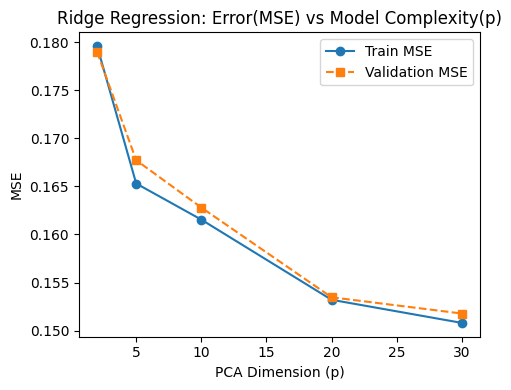

In [30]:
plt.figure(figsize=(5,4))

plt.plot(p_values, complexity_results['train_mse'], marker='o', label='Train MSE')
plt.plot(p_values, complexity_results['val_mse'], marker='s', linestyle='--', label='Validation MSE')

plt.xlabel('PCA Dimension (p)')
plt.ylabel('MSE')
plt.title('Ridge Regression: Error(MSE) vs Model Complexity(p)')
plt.legend()

plt.tight_layout()
plt.show()

### Experiment3: Choose best model and test performance

Determine best out of Ridge and Lasso

In [31]:
if avg_ridge_mse[best_ridge_idx] < avg_lasso_mse[best_lasso_idx]:
    best_model_type = 'Ridge'
    best_lambda = best_ridge_lambda
else:
    best_model_type = 'Lasso'
    best_lambda = best_lasso_lambda

print(f"\nBest Model Overall: {best_model_type} with Lambda = {best_lambda}")


Best Model Overall: Ridge with Lambda = 100


Compute best test accuracy

In [32]:
W_all = []

for k in classes:
    y_train_k = get_ovr_targets(y_train, k).reshape(-1, 1)
    
    if best_model_type == 'Ridge':
        W_k = ridge_regression_fit(X_train_10, y_train_k, best_lambda)
    else:
        W_k = lasso_regression_fit(X_train_10, y_train_k, best_lambda).reshape(-1,1)
    
    W_all.append(W_k)

W_all = np.hstack(W_all)

scores = X_test_10 @ W_all 
y_pred = np.argmax(scores, axis=1)

accuracy = compute_accuracy(y_test, y_pred)

print(f"\nFinal Test Accuracy ({best_model_type}): {accuracy:.4f}")


Final Test Accuracy (Ridge): 0.9514
